# Hidden Markov Model (HMM)

HMM is a statistical model used to describe a Markov process with unobserved (hidden) states.

## Model Description
It is defined by the following 5 core elements:

1. **Hidden States**: The underlying states that actually exist but can not be observed directly.
    $$ S={s_1, s_2, ..., s_N} \text{,} \quad \text{with } N \text{ possible hidden states}$$
<br>

2. **Observations**: The data or outcomes that we can actually see and measure.
    $$ V={v_1, v_2, ..., v_M} \text{,} \quad \text{with } M \text{ possible observations}$$
<br>

3. **State Transition Probability Matrix**: Defines the probability of moving from one hidden state to another.

    $$ A_{N \times N}= [a_{i,j}]= \begin{bmatrix}
    a_{1,1} & a_{1,2} & \dots & a_{1,N} \\
    a_{2,1} & a_{2,2} & \dots & a_{2,N} \\
    \vdots & \vdots &  & \vdots \\
    a_{N,1} & a_{N,2} & \dots & a_{N,N} \\
    \end{bmatrix} $$
    
    <br>
    

    - $\forall i = 1, \dots, N$ and $\forall j = 1, \dots, N$

    - $a_{i,j} = P(q_{t+1} = s_j | q_t = s_i)$ is the probability of transitioning from state $s_i$ to state $s_j$, where $q_t$ is the hidden state at time $t$.

    - The sum of each row must equal 1:  $\sum_{i} a_{i,j} = 1.0$.
    
<br>

4. **Observation Emission Probability Matrix**: Defines the probability that a specific hidden state "emits" or produces a specific observation.

    $$ B_{N \times M} = [b_j(v_k)] = \begin{bmatrix}
        [ b_{1}(v_1) & b_{1}(v_2) & \dots & b_{1}(v_{M}) ] \\
        [ b_{2}(v_1) & b_{2}(v_2) & \dots & b_{2}(v_{M}) ] \\
        \vdots & \vdots &  & \vdots \\
        [ b_{N}(v_1) & b_{N}(v_2) & \dots & b_{N}(v_{M}) ] \\
        \end{bmatrix}
    $$
    <br>
    
    - $\forall j = 1, \dots, N$ and $\forall v_k \in V \text{, where } k = 1, \dots, M$

    - $b_{j}(k) = P( O_t = v_k | q_t = s_j)$  is the probability of observing $v_{k}$ given that the system is currently in hidden state $s_j$, where $O_t$ is the observation at time $t$ and $q_t$ is the hidden state at time $t$.
    
    - The sum of each row must equal 1: $\sum_{k} b_j(v_k) = 1$.

<br>

5. **Initial State Probability Distribution**: The probability of starting in each hidden state at time $t = 1$.

    $$ \pi_i = P(q_1 = s_i)  $$





## The Fundamental Assumptions of HMM
To make calculations mathematically feasible, and HMM relies on two strict assumptions:

1. Current state depends only on the previous state

    - The hidden state at time $t$ depends **exclusively** on the hidden state at time $t-1$. It is completely independent od any earlier history.

    - $P(q_{t+1} | q_t, q_{t-1}, ... q_0, o_t, o_{t-1}, ...) = P(q_{t+1} | q_t)$ 


2. Observation depends only on the state at the same moment.

    - The observation generated at time $t$ depends exclusively on the current hidden state at time $t$.

    - $P(o_{t+1} | q_{t+1}, q_t, ... q_0, o_{t+1}, o_t, ...) = P(o_{t+1} | q_{t+1})$


## Predict Hidden states from observations using Viterbi Algorithm

The Viterbi Algorithm is a **dynamic programming** algorithm used to find the most likely sequence of hidden states (called the Viterbi path) that results in a sequence of observed events, given a Hidden Markov Model (HMM). To construct the model, we first assume that:
- $o_t$ is the observation at time $t$.
- $\delta_{t}(i)$ is the maximum probability that the HMM is in hidden state $s_i$ at time $t$.
- $\delta_{t-1}(i)$ is the probability of the best path up to the previous step ending in state $s_i$.
- $\psi_t(i)$ is a backpointer matrix used to log which previous state $s_i$ yielded the maximum probability.

#### Step 1: Initialization
For $t=1$ and $ 1 \leq i \leq N $,
$$ \delta_{1}(i) = \pi_{i} \cdot b_{i}(o_{1}) 
\quad \text{ and } \quad
\psi_t(i) = 0 $$


#### Step 2: Recursive steps 
For $t=2, 3, \dots,T$ and $ 1 \leq j \leq N $,
$$ \delta_{t}(j) = \max_{1 \leq i \leq N} \big[ \delta_{t-1}(i) \cdot a_{i,j} \big] \cdot b_{j}(o_t) 
\quad \text{ and } \quad
\psi_t(j) = \argmax_{1 \leq i \leq N} \big[ \delta_{t-1}(i) \cdot a_{i,j} \big] $$


#### Step 3: Termination
For $t=T$, identify the highest total probability across all terminal states at the final sequence position:

$$ P^{*} = \max_{1 \leq i \leq N} \psi_T(i) 
\quad \text{ and } \quad
q^{*}_{T} = \argmax_{1 \leq i \leq N} \psi_T(i) $$

#### Step 4: Path Backtracking
From $t = T-1$ down to 1, trace backward through the saved $\psi$ matrix to reconstruct the sequence of hidden states:
$$ q^{*}_{t} = \psi_{t+1}(q^{*}_{t+1}) $$




### Numerical Stability in Practice: Log-Space Viterbi

In practical computer systems processing long DNA sequences, multiplying continuous probability values yields numeric underflow errors where values truncate directly to zero.To solve this, equations are transformed using **natural logarithms**, turning raw multiplications into stable additions:

$$\log \delta_{t}(j) = \max _{i} \left[ \log \delta_{t-1}(i) + \log a_{i,j} \right] + 
\log b_{j}(t) $$

## The HMM implementation 

The HMM implementation is located in [`hmm.py`](./hmm.py).

- `hmm_generator` is used to generate sequence from given hidden states matrix and emission matrix.
- `log_viterbi` is a custom function used to compute the most likely sequence of hidden states using the Viterbi algorithm in log-space.
- `viterbi_hmmlearn` is used to run HMM prediction model using the `hmmlearn` library. The `hmmlearn` [library](https://github.com/hmmlearn/hmmlearn) is implemented in Cython for high performance and utilizes log-space arithmetic to prevent numerical underflow. The `.predict()` method of the `hmmlearn.hmm.CategoricalHMM` model natively uses the Viterbi algorithm to decode hidden states.

Theoretically, `log_viterbi` and `viterbi_hmmlearn` should yield identical results.

In [136]:
%load_ext autoreload
%autoreload 2
from hmm import hmm_generator, log_viterbi, viterbi_hmmlearn

# draw result
from hmm_validate import draw_parallel_step_lines

# CpG island
from cpg_island import cal_block_size, analyze_cgi_for_diff_states

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Excercise 1: Generate hidden states and observations sequense.

### CpG Island 

According to the definition of CpG island follows the cratiria:

- Length of CpG island is greater than 200 bp.
- GC Content is Greater than 50%.
- Observed/Expected (O/E) Ratio of CpGs is greater than 0.60.


### CpG Island vs. Background Sequence
There are two hidden stats: whether it is located on CpG island or background region.
$$ S = [ \text{'BG'}, \text{'CG'}] $$

The system tends to stay in its current state. The state transition probability matrix is defined as below.
$$ A = \begin{bmatrix}
0.95 & 0.05  \\
0.15 & 0.85  \\
\end{bmatrix} $$

The observation emission probability matrix:
$$ B = \begin{bmatrix}
0.25 & 0.25 & 0.25 & 0.25  \\
0.10 & 0.40 & 0.40 & 0.10  \\
\end{bmatrix} $$

The initial state probability distribution:
$$ \pi = [0.90, 0.10 ] $$


<br><br>
⚠️ **NOTE**: Unlike the previous Markov chain, where the next base was determined by the prior base, this model's base probability distribution depends exclusively on the states. Consequently, it captures states transition frequency within two continuous hidden states rather than sequential patterns (bases).


In [139]:
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt

In [131]:
def run_cpg_test(length: int) -> tuple:
    states = ["BG", "CG"]
    bases = ["A", "C", "G", "T"]
    trans = np.array([[0.85, 0.15], [0.15, 0.85]])
    emis = np.array([[0.25, 0.25, 0.25, 0.25], [0.10, 0.40, 0.40, 0.10]])
    pi = np.array([0.90, 0.10])
    return hmm_generator(1000, states, bases, trans, emis, pi)


def get_hidden_indices(hidden_path: list) -> NDArray:
    state_map = {state: idx for idx, state in enumerate(["BG", "CG"])}
    return np.array([state_map.get(s) for s in hidden_path])

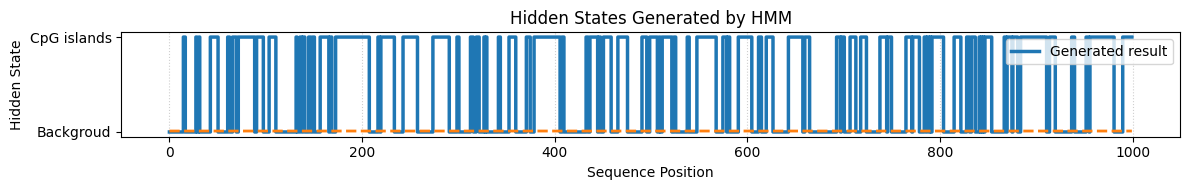

In [132]:
hidden_path, observed_sequence = run_cpg_test(1000)
generated = get_hidden_indices(hidden_path)
empty = np.array([0] * len(hidden_path))

draw_parallel_step_lines(
    generated,
    empty,
    figsize=(12, 2),
    true_label="Generated result",
    predict_label="",
    subtitle="Hidden States Generated by HMM",
    y_labels=["Backgroud", "CpG islands"],
)

### HMM Duration Limitations: Over-Switching Artifacts in Hidden State Generation

#### The generated hidden states seem to switch frequently. To invastigate the switching frequencies of the hidden states, I calculated the mean and standard deviation of the state block sizes.  

In [143]:
sample = 100
cg_statistic = {"BG": [], "CG": []}
blocksize = {"BG": [], "CG": []}
for _ in range(sample):
    hidden_path, observed_sequence = run_cpg_test(1000)
    result = analyze_cgi_for_diff_states(hidden_path, observed_sequence)
    cg_statistic["BG"].append(result.get("BG"))
    cg_statistic["CG"].append(result.get("CG"))
    result = cal_block_size(hidden_path)
    blocksize["BG"].append(result.get("BG"))
    blocksize["CG"].append(result.get("CG"))

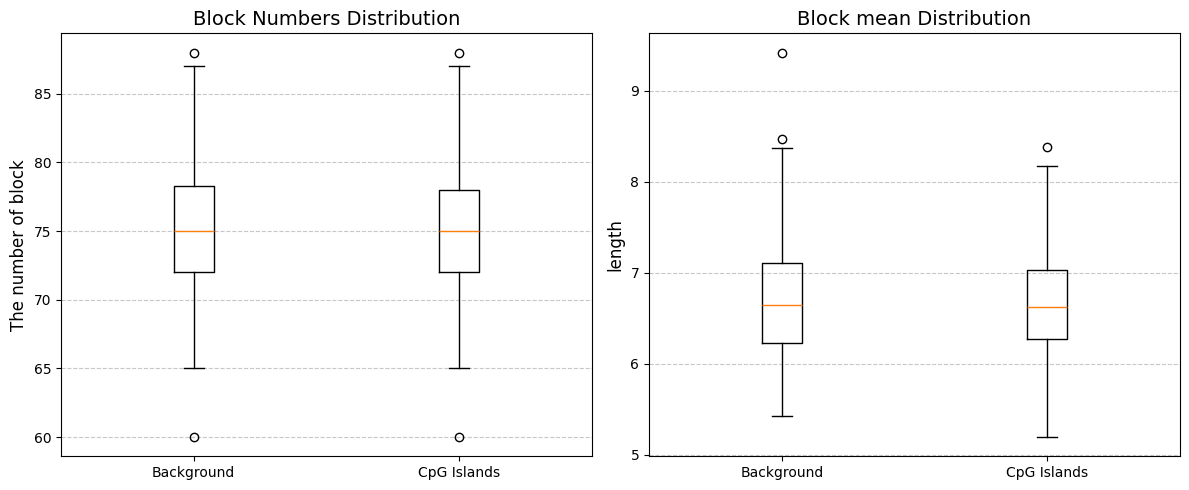

In [147]:
bg_block_number = [len(r) for r in blocksize.get("BG")]
cg_block_number = [len(r) for r in blocksize.get("CG")]
bg_block_mean = [np.array(r).mean() for r in blocksize.get("BG")]
cg_block_mean = [np.array(r).mean() for r in blocksize.get("CG")]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.boxplot(
    [bg_block_number, cg_block_number], tick_labels=["Background", "CpG Islands"]
)
ax1.set_title("Block Numbers Distribution", fontsize=14)
ax1.set_ylabel("The number of block", fontsize=12)
ax1.grid(axis="y", linestyle="--", alpha=0.7)

ax2.boxplot([bg_block_mean, cg_block_mean], tick_labels=["Background", "CpG Islands"])
ax2.set_title("Block mean Distribution", fontsize=14)
ax2.set_ylabel("length", fontsize=12)
ax2.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

Looking into the simulation results, we can see that the states switched frequently (swithched around 150 times for a 1000bp sequence). 

This occurs due to the HMM assumption that the current state is only affected by the previous state. Because the transition probability is **constant**, the duration of remaining in the same hidden state must follow a **geometric distribution**. 

No matter what the constant probability is, the probability of staying in the same hidden state approaches zero as the sequence length gets larger. In our cases, the avarage duration is only 6-7 bps.

#### Comparing the GC content and O/E ratio between background regions and CpG islands.

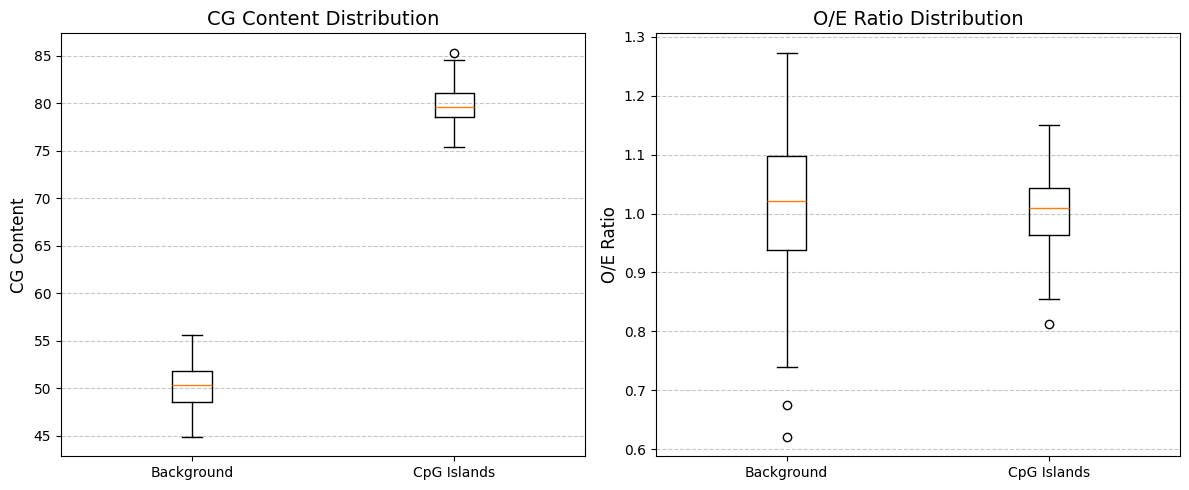

In [148]:
bg_cg_content = [r.get("gc_content") for r in cg_statistic.get("BG")]
cg_cg_content = [r.get("gc_content") for r in cg_statistic.get("CG")]
bg_oe_ratio = [r.get("oe_ratio") for r in cg_statistic.get("BG")]
cg_oe_ratio = [r.get("oe_ratio") for r in cg_statistic.get("CG")]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.boxplot([bg_cg_content, cg_cg_content], tick_labels=["Background", "CpG Islands"])
ax1.set_title("CG Content Distribution", fontsize=14)
ax1.set_ylabel("CG Content", fontsize=12)
ax1.grid(axis="y", linestyle="--", alpha=0.7)

ax2.boxplot([bg_oe_ratio, cg_oe_ratio], tick_labels=["Background", "CpG Islands"])
ax2.set_title("O/E Ratio Distribution", fontsize=14)
ax2.set_ylabel("O/E Ratio", fontsize=12)
ax2.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

While the GC content matches our parameter settings, the O/E ratio looks nothing like a true CpG island. 

It is because that the current base depends only on the current hidden state, the model cannot memorize previously generated bases or track how many C and G bases have been generated. As a result, it cannot generate a CpG region with a sequential C→G pattern; instead, it produces regions with a high frequency of C and G bases.

#### Conclusion: Using an HMM to generate sequences that mimick genome sequences containing CpG islands is not practical. 

However, how does it perform when detecting CpG islands in a given sequence?


## Excercise 2: Conduct Log-Space Viterbi Algorithm

Given an observation sequence generated by our HMM generator, we apply the log-space Viterbi algorithm to predict the sequence of hidden states.

In [110]:
states = ["BG", "CG"]
bases = ["A", "C", "G", "T"]
transition = np.array([[0.85, 0.15], [0.15, 0.85]])
emission = np.array([[0.25, 0.25, 0.25, 0.25], [0.10, 0.40, 0.40, 0.10]])
pi = np.array([0.50, 0.50])

# Generate observations
hidden_path, observed_sequence = hmm_generator(
    500, states, bases, transition, emission, pi
)
state_map = {state: idx for idx, state in enumerate(states)}
groundtruth = np.array([state_map.get(b) for b in hidden_path])
base_map = {base: idx for idx, base in enumerate(bases)}
obs = np.array([base_map.get(b) for b in observed_sequence])

# Conduct manual version
best_path, delta, psi = log_viterbi(obs, 2, pi, transition, emission)

# Conduct hmmlearn version
hmm_best_path = viterbi_hmmlearn(obs, 2, pi, transition, emission)

Print the ground truth hidden states and prediction hidden states.

In [111]:
print(f"Ground:    {','.join(hidden_path)}")
print(f"manual:    {','.join([states[i] for i in best_path])}")
print(f"hmmlearn:  {','.join([states[i] for i in hmm_best_path])}")

Ground:    BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,CG,CG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,BG,CG,CG,CG,BG,BG,BG,BG,BG,BG,BG,BG,BG,CG,CG,BG,BG,BG,BG,CG,CG,CG,CG,CG,CG,CG,BG,BG,BG,BG,CG,CG,CG,BG,BG,BG,BG,BG,BG,BG,BG,BG,CG,CG,CG,BG,CG,CG,CG,BG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,BG,BG,BG,CG,CG,CG,CG,CG,CG,CG,CG,CG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,CG,CG,CG,CG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,BG,BG,BG,CG,CG,CG,CG,CG,CG,CG,BG,BG,BG,CG,CG,CG,CG,CG,CG,CG,BG,BG,BG,BG,BG,BG,BG,CG,BG,BG,BG,BG,BG,CG,CG,CG,CG,CG,CG,BG,BG,BG,BG,CG,CG,CG,CG,CG,CG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,CG,BG,CG,CG,CG,CG,CG,CG,CG,CG,CG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG,BG

## Excercise 3: Evaluate Viterbi Algorithm Prediction Result

The visualization implementation is located in [`hmm_validate.py`](./hmm_validate.py).

#### Method 1: Parallel Step Lines

This method plots the true path and predicted path as two distinct horizontal step lines. It makes it very easy to spot exactly where the Viterbi algorithm made a mistake.

#### Method 2: Dual-Track Color Blocks 

For long DNA sequence, parallel step lines become unreadable. We can Draw solid colored blocks (like a genome browser track) to visualize our result.

#### Method 3: Confusion Matrix

While tracks show where errors happen, a confusion matrix tells you what kind of mistakes your Viterbi algorithm is making overall  (e.g., misclassifying State A as State B).

In [47]:
%load_ext autoreload
%autoreload 2
from hmm_validate import (
    draw_parallel_step_lines,
    draw_dual_track_color_blocks,
    draw_confusion_matrix,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Results

### Result 1: Consistent output between ustom function and the hmmlearn model

The results demonstrate a consistent output between our custom function and the hmmlearn model, validating the correctness of our implementation.

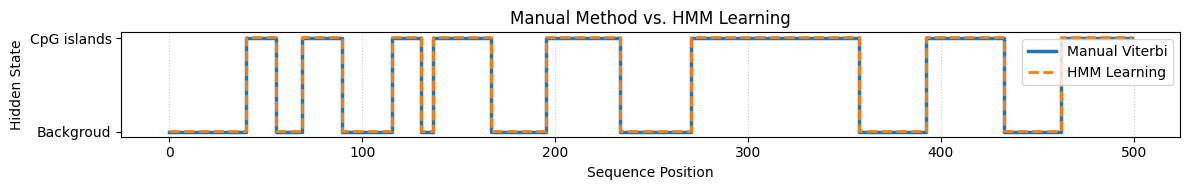

In [112]:
draw_parallel_step_lines(
    best_path,
    hmm_best_path,
    figsize=(12, 2),
    true_label="Manual Viterbi",
    predict_label="HMM Learning",
    subtitle="Manual Method vs. HMM Learning",
    y_labels=["Backgroud", "CpG islands"],
)

### Result 2: Limitations of the Viterbi Algorithm in CpG Island Differentiation

The definition of CpG island should follow cratiria:
 - Greater than 200 (or 500) base pairs (bp).
 - GC Content: Greater than 50%.
 - Observed/Expected (O/E) Ratio of CpGs must be greater than 0.60

Looking into the generated observations and hidden states, we can see that the states switched frequently. This occurs due to the HMM assumption that the current state is only affected by the previous state. Because the transition probability is constant, the duration of remaining in the same hidden state must follow a geometric distribution. No matter what the constant probability is, the probability of staying in the same hidden state approaches zero as the sequence length gets larger. Consequently, most of the hidden states changed within 100 bases.



The Viterbi algorithm did not perform well in distinguishing CpG islands from background genome. This is because the HMM can only control the transition from the current state to the next state, and cannot memorize the history of the observation sequence. Therefore, the generated observations with CpG hidden states do not necessarily move from C to G; they just represent higher frequencies of C and G. Although the results show that most of the transition cut-off points seem to align with the ground truth transition points, the model still fails to detect many of them.

To address this, using a **higher-order HMM** or a **Conditional Random Field (CRF)** could help capture longer-term sequence dependencies.

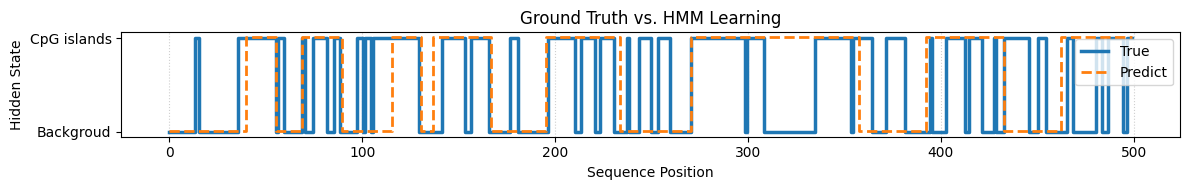

In [113]:
draw_parallel_step_lines(
    groundtruth,
    hmm_best_path,
    figsize=(12, 2),
    subtitle="Ground Truth vs. HMM Learning",
    y_labels=["Backgroud", "CpG islands"],
)

### Result 3: 

If I set a perfect CG region (100% C->G) with background sequence that is uniformly distributed and with out C-G inside, we can get precise hidden states translating boungray. The model can be a good prediction tool when the sequence have extremely different behavior of bases frequencies and sequence patterm. However, it is not realistic according to the CpG island definition:
 - Greater than 200 (or 500) base pairs (bp).
 - GC Content: Greater than 50%.
 - Observed/Expected (O/E) Ratio of CpGs must be greater than 0.60

In [106]:
states = ["BG", "CG"]
bases = ["A", "C", "G", "T"]
transition = np.array([[0.85, 0.15], [0.15, 0.85]])
emission = np.array([[0.25, 0.25, 0.25, 0.25], [0.10, 0.40, 0.40, 0.10]])
pi = np.array([0.50, 0.50])

truth_hidden = (
    ["CG"] * 90
    + ["BG"] * 60
    + ["CG"] * 10
    + ["BG"] * 40
    + ["CG"] * 10
    + ["BG"] * 20
    + ["CG"] * 400
    + ["BG"] * 40
)
sequence = (
    "CG" * 45
    + "TAGACTGACGCGACTGACTT" * 3
    + "CG" * 5
    + "TAGACTGACGCGACTGACTT" * 2
    + "CG" * 5
    + "TAGACTGACGCGACTGACTT"
    + "CG" * 200
    + "TAGACTGACGCGACTGACTT" * 2
)
obs = np.array([base_map.get(b) for b in sequence])

best_path, delta, psi = log_viterbi(obs, 2, pi, transition, emission)
groundtruth = np.array([state_map.get(b) for b in truth_hidden])

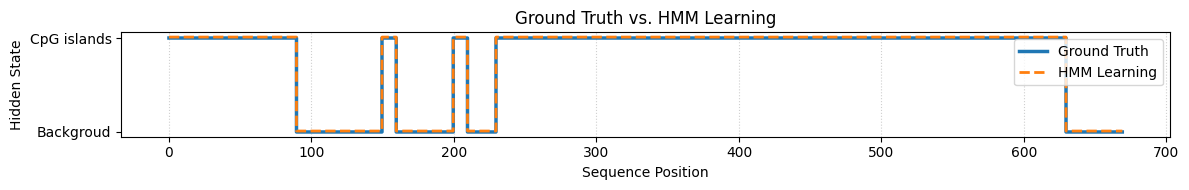

In [107]:
draw_parallel_step_lines(
    groundtruth,
    best_path,
    figsize=(12, 2),
    true_label="Ground Truth",
    predict_label="HMM Learning",
    subtitle="Ground Truth vs. HMM Learning",
    y_labels=["Backgroud", "CpG islands"],
)

## Conclusion 

### HMM Limitations in Sequence Modeling

#### Lack of Control over Continuous Hidden State Lengths
Standard HMMs have a **constant** transition probability, forcing the hidden state lengths to follow a **geometric distribution**. This makes it impossible to naturally model the realistic, fixed-range lengths of specific domains; for example, generating CpG islands of approximately 300–3,000 bp.


### Limitation of Viterbi Algorithm
Because the generated sequence lacks strong **global features**, the Viterbi algorithm easily gets confused by local random variations in the background sequence, leading to false positives or premature state exits.


#### Limitation of Modeling CpG Island 
We observed short CpG regions in our generator, which is consistent with the limitations of the standard HMM model. Moreover, because the current base depends only on the current hidden state, the model cannot memorize previously generated bases or track how many C and G bases have been generated. As a result, it cannot generate a CpG region with a sequential C→G pattern; instead, it produces regions with a high frequency of C and G bases.


#### Limitation of Modeling Tandem Repeats
Tandem repeats require a mechanism that remembers the exact pattern unit (e.g., CAG) and counts how many times it copies itself. A standard HMM completely lacks this memory. To successfully model and predict tandem repeats, we need other approaches to handle periodic structures and variable lengths. 






